PSNR (luminance) vs original:
  noisy:    28.140257
  Haar:     30.730589
  LapPyr:   26.88614

Entropy after quantization (bits/symbol, per band):
Wavelet (Haar):
  LL      : 13.353
  L0_LH   : 7.894
  L0_HL   : 7.972
  L0_HH   : 7.551
  L1_LH   : 8.583
  L1_HL   : 8.814
  L1_HH   : 8.097
  L2_LH   : 9.335
  L2_HL   : 9.680
  L2_HH   : 8.866
  L3_LH   : 10.156
  L3_HL   : 10.559
  L3_HH   : 9.574

Laplacian pyramid:
  L0      : 7.926
  L1      : 7.259
  L2      : 7.103
  coarse  : 9.604


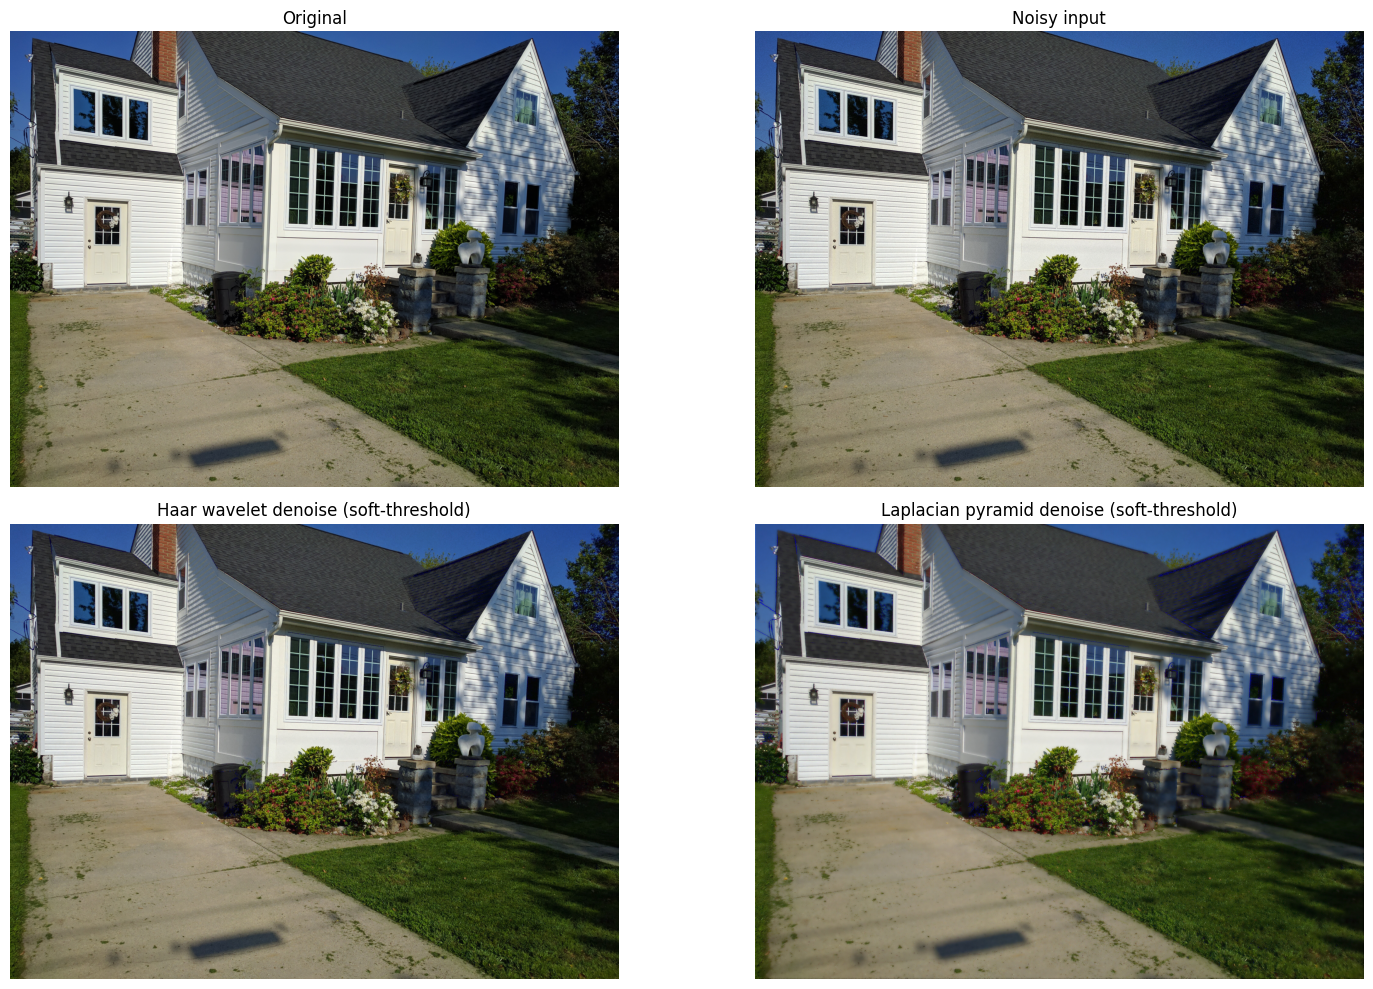

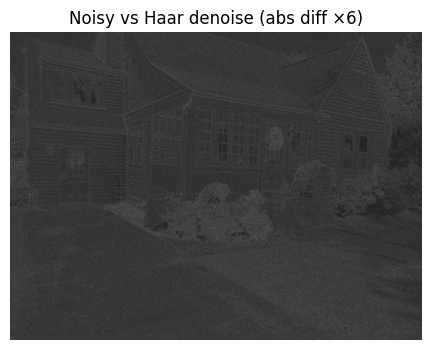

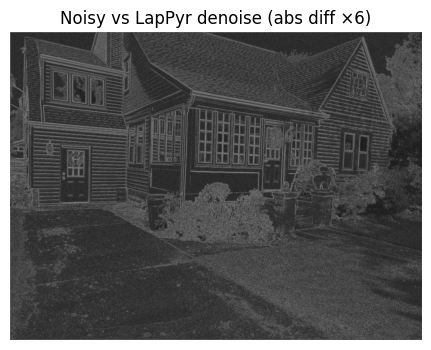

In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

# ----------------------------
# Paths
# ----------------------------
img_path = os.path.join("..", "Files", "Random_Images", "houses_3.jpg")

# ----------------------------
# Basic helpers
# ----------------------------
def clip01(x): return np.clip(x, 0.0, 1.0)

def load_rgb01(path):
    im = Image.open(path).convert("RGB")
    return np.asarray(im).astype(np.float32) / 255.0

def rgb_to_luma709(rgb):
    r,g,b = rgb[...,0], rgb[...,1], rgb[...,2]
    return 0.2126*r + 0.7152*g + 0.0722*b

def reapply_luma_by_scaling(rgb, Y_new, eps=1e-6):
    Y_old = rgb_to_luma709(rgb)
    s = Y_new / (Y_old + eps)
    return clip01(rgb * s[...,None])

def soft_threshold(x, T):
    # C0 coring (soft-threshold)
    return np.sign(x) * np.maximum(np.abs(x) - T, 0.0)

def psnr(a, b):
    mse = np.mean((a-b)**2)
    if mse < 1e-12:
        return 99.0
    return 10*np.log10(1.0/mse)

# ----------------------------
# Haar wavelet (orthonormal) 2D, multi-level
# ----------------------------
def haar_dwt2_level(I):
    """
    One-level 2D Haar DWT for grayscale image I (H x W), requires even dims.
    Returns LL, LH, HL, HH (each H/2 x W/2)
    """
    H, W = I.shape
    assert H % 2 == 0 and W % 2 == 0

    a = I[0::2, 0::2]
    b = I[0::2, 1::2]
    c = I[1::2, 0::2]
    d = I[1::2, 1::2]

    # Orthonormal-ish scaling with /2
    LL = (a + b + c + d) / 2.0
    LH = (a - b + c - d) / 2.0  # horizontal detail
    HL = (a + b - c - d) / 2.0  # vertical detail
    HH = (a - b - c + d) / 2.0  # diagonal detail
    return LL, LH, HL, HH

def haar_idwt2_level(LL, LH, HL, HH):
    """
    Inverse of haar_dwt2_level.
    """
    h, w = LL.shape
    a = (LL + LH + HL + HH) / 2.0
    b = (LL - LH + HL - HH) / 2.0
    c = (LL + LH - HL - HH) / 2.0
    d = (LL - LH - HL + HH) / 2.0

    H, W = 2*h, 2*w
    I = np.zeros((H, W), dtype=np.float32)
    I[0::2, 0::2] = a
    I[0::2, 1::2] = b
    I[1::2, 0::2] = c
    I[1::2, 1::2] = d
    return I

def haar_dwt2(I, levels=3):
    """
    Multi-level DWT.
    Returns:
      LL (coarsest)
      bands: list of (LH, HL, HH) from finest->coarsest? We'll store per level.
    """
    bands = []
    cur = I
    for _ in range(levels):
        LL, LH, HL, HH = haar_dwt2_level(cur)
        bands.append((LH, HL, HH))
        cur = LL
    return cur, bands  # cur is coarsest LL

def haar_idwt2(LL, bands):
    """
    Reconstruct from coarsest LL and list of bands in the same order produced by haar_dwt2.
    """
    cur = LL
    for (LH, HL, HH) in reversed(bands):
        cur = haar_idwt2_level(cur, LH, HL, HH)
    return cur

# ----------------------------
# Laplacian pyramid (binomial kernel) multi-level
# ----------------------------
k1d = np.array([1,4,6,4,1], dtype=np.float32) / 16.0

def blur_binomial(img):
    return cv2.sepFilter2D(img, -1, k1d, k1d, borderType=cv2.BORDER_REFLECT)

def pyr_down(img):
    return blur_binomial(img)[::2, ::2]

def pyr_up(img, out_shape):
    H, W = out_shape
    up = np.zeros((H, W), dtype=np.float32)
    up[::2, ::2] = img
    k_up = (k1d * 2.0).astype(np.float32)  # 2 per dim => 4 overall
    return cv2.sepFilter2D(up, -1, k_up, k_up, borderType=cv2.BORDER_REFLECT)

def gaussian_pyr(I, levels):
    G = [I]
    cur = I
    for _ in range(1, levels):
        cur = pyr_down(cur)
        G.append(cur)
    return G

def laplacian_pyr(I, levels):
    G = gaussian_pyr(I, levels)
    L = []
    for i in range(levels-1):
        exp = pyr_up(G[i+1], G[i].shape)
        L.append(G[i] - exp)
    L.append(G[-1])
    return L

def laplacian_recon(L):
    cur = L[-1]
    for i in range(len(L)-2, -1, -1):
        cur = pyr_up(cur, L[i].shape) + L[i]
    return cur

# ----------------------------
# Entropy after quantization
# ----------------------------
def band_entropy(coeffs, qstep):
    """
    coeffs: ndarray
    qstep: quantization step in same units (here [0,1])
    """
    q = np.round(coeffs / qstep).astype(np.int32)
    vals, counts = np.unique(q, return_counts=True)
    p = counts.astype(np.float64) / counts.sum()
    H = -np.sum(p * np.log2(p + 1e-12))
    return float(H)

# ----------------------------
# Experiment on houses_3: denoising + entropy
# ----------------------------
rgb = load_rgb01(img_path)
Y = rgb_to_luma709(rgb)

# Make a noisy version (simulate low-light-ish Gaussian noise)
rng = np.random.default_rng(0)
sigma_noise = 0.04
Y_noisy = clip01(Y + rng.normal(0, sigma_noise, Y.shape).astype(np.float32))
rgb_noisy = reapply_luma_by_scaling(rgb, Y_noisy)

# Choose decomposition depth
levels = 4

# --- Wavelet denoising (Haar) ---
LL, bands = haar_dwt2(Y_noisy, levels=levels)

# Threshold per level (coarser levels: usually smaller threshold)
# A simple schedule: T_l = base * 0.7^l
T0 = 0.06
bands_denoised = []
for l, (LH, HL, HH) in enumerate(bands):
    T = T0 * (0.7**l)
    bands_denoised.append((
        soft_threshold(LH, T),
        soft_threshold(HL, T),
        soft_threshold(HH, T),
    ))

Y_wave = clip01(haar_idwt2(LL, bands_denoised))
rgb_wave = reapply_luma_by_scaling(rgb, Y_wave)

# --- Laplacian pyramid denoising ---
L = laplacian_pyr(Y_noisy, levels=levels)

# Threshold each Laplacian band (not the last lowpass)
T0p = 0.05
L_d = []
for i in range(levels-1):
    T = T0p * (0.7**i)
    L_d.append(soft_threshold(L[i], T))
L_d.append(L[-1])  # keep coarsest
Y_pyr = clip01(laplacian_recon(L_d))
rgb_pyr = reapply_luma_by_scaling(rgb, Y_pyr)

# --- Compute entropy per band (compression-style) ---
# "1/4 gray level" for 8-bit means step = 0.25/255 in [0,1]
qstep = 0.25 / 255.0

# Wavelet entropies: three bands per level + LL
wave_ent = {"LL": band_entropy(LL, qstep)}
for l,(LH,HL,HH) in enumerate(bands):
    wave_ent[f"L{l}_LH"] = band_entropy(LH, qstep)
    wave_ent[f"L{l}_HL"] = band_entropy(HL, qstep)
    wave_ent[f"L{l}_HH"] = band_entropy(HH, qstep)

# Laplacian pyramid entropies: each detail band + coarsest
pyr_ent = {f"L{i}": band_entropy(L[i], qstep) for i in range(levels-1)}
pyr_ent["coarse"] = band_entropy(L[-1], qstep)

# --- Show results ---
print("PSNR (luminance) vs original:")
print("  noisy:   ", psnr(Y, Y_noisy))
print("  Haar:    ", psnr(Y, Y_wave))
print("  LapPyr:  ", psnr(Y, Y_pyr))

print("\nEntropy after quantization (bits/symbol, per band):")
print("Wavelet (Haar):")
for k,v in wave_ent.items():
    print(f"  {k:8s}: {v:.3f}")

print("\nLaplacian pyramid:")
for k,v in pyr_ent.items():
    print(f"  {k:8s}: {v:.3f}")

plt.figure(figsize=(16,10))
plt.subplot(2,2,1); plt.imshow(rgb);       plt.title("Original"); plt.axis("off")
plt.subplot(2,2,2); plt.imshow(rgb_noisy); plt.title("Noisy input"); plt.axis("off")
plt.subplot(2,2,3); plt.imshow(rgb_wave);  plt.title("Haar wavelet denoise (soft-threshold)"); plt.axis("off")
plt.subplot(2,2,4); plt.imshow(rgb_pyr);   plt.title("Laplacian pyramid denoise (soft-threshold)"); plt.axis("off")
plt.tight_layout(); plt.show()

# Optional: difference images to make changes visible
def show_diff(a, b, title, scale=6.0):
    d = np.clip(np.abs(a-b)*scale, 0, 1)
    plt.figure(figsize=(6,4))
    plt.imshow(d, cmap="gray")
    plt.title(f"{title} (abs diff ×{scale:g})")
    plt.axis("off")
    plt.show()

show_diff(Y_noisy, Y_wave, "Noisy vs Haar denoise")
show_diff(Y_noisy, Y_pyr,  "Noisy vs LapPyr denoise")
